# CHA Experiment 1: Qwen2.5-7B Context Window Degradation

**Runtime:** ~2-4 hours on T4 GPU

**Before running:** Go to Runtime → Change runtime type → Select **T4 GPU**

**IMPORTANT:** Cell 2 installs `pciutils` so Ollama can detect the GPU. Without it, Ollama falls back to CPU-only (extremely slow for 7B).

---

## Cell 1: Mount Google Drive & Set API Key

Upload your `CHA_Experiment_1` folder (or zip) to Google Drive first.

In [9]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os

# Set your project path on Drive
PROJECT_DIR = '/content/drive/MyDrive/CHA_Experiment_1'
assert os.path.exists(PROJECT_DIR), f'Upload CHA_Experiment_1 to Google Drive first! Not found at {PROJECT_DIR}'

# Set API key — either from Colab secrets or paste directly
# Option A: Use Colab Secrets (recommended) — add ANTHROPIC_API_KEY in the key icon on the left
try:
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
    print('API key loaded from Colab Secrets')
except:
    # Option B: Paste directly (less secure)
    ANTHROPIC_API_KEY = ''  # <-- paste your key here if not using Secrets

if not ANTHROPIC_API_KEY:
    # Option C: Read from .env on Drive
    env_path = os.path.join(PROJECT_DIR, '.env')
    if os.path.exists(env_path):
        with open(env_path) as f:
            for line in f:
                if line.startswith('CHA_EXPERIMENT_SONNET_KEY='):
                    ANTHROPIC_API_KEY = line.strip().split('=', 1)[1]
                    print('API key loaded from .env on Drive')
                    break

assert ANTHROPIC_API_KEY, 'No API key found! Set it via Colab Secrets, paste above, or ensure .env is on Drive.'
os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
os.environ['CHA_EXPERIMENT_SONNET_KEY'] = ANTHROPIC_API_KEY
print(f'Project dir: {PROJECT_DIR}')
print(f'API key: ...{ANTHROPIC_API_KEY[-8:]}')
print('Scripts:', len([f for f in os.listdir(os.path.join(PROJECT_DIR, 'scripts')) if f.endswith('.json')]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
API key loaded from .env on Drive
Project dir: /content/drive/MyDrive/CHA_Experiment_1
API key: ...9tYw8wAA
Scripts: 100


## Cell 2: Install Ollama & Pull Qwen2.5-7B

**Re-run this cell after every disconnect.** Takes ~5 minutes (model is ~4.7 GB).

In [4]:
%%bash
# Install pciutils (provides lspci) so Ollama can detect the T4 GPU
apt-get update -qq && apt-get install -y -qq zstd pciutils > /dev/null 2>&1
# Verify GPU is visible
echo "GPU check:"
lspci | grep -i nvidia
# Install Ollama (will now detect GPU and install CUDA dependencies)
curl -fsSL https://ollama.com/install.sh | sh 2>&1 | tail -5
echo 'Ollama installed.'

GPU check:
00:04.0 3D controller: NVIDIA Corporation TU104GL [Tesla T4] (rev a1)
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama installed.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [5]:
import subprocess, time

# Start Ollama server in background (use full path in case PATH not updated)
proc = subprocess.Popen(
    ['/usr/local/bin/ollama', 'serve'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(5)
print(f'Ollama server started (PID {proc.pid})')

# Pull qwen2.5:7b model
!/usr/local/bin/ollama pull qwen2.5:7b
print('\nModel ready!')

Ollama server started (PID 7709)


Model ready!


## Cell 3: Install Python Dependencies & Speed Test

In [7]:
!pip install -q ollama anthropic python-dotenv numpy scipy matplotlib

import ollama, time
t0 = time.time()
resp = ollama.chat(model='qwen2.5:7b', messages=[
    {'role': 'system', 'content': 'You are Aria, a warm AI support agent.'},
    {'role': 'user', 'content': 'Hi, I have been feeling anxious about an upcoming party.'}
], options={'temperature': 0.7, 'num_predict': 150, 'num_ctx': 16384})
elapsed = time.time() - t0
tokens = resp.get('eval_count', 0)
rate = tokens / elapsed if elapsed > 0 else 1
print(f'Speed: {tokens} tokens in {elapsed:.1f}s = {rate:.1f} t/s')
print(f'Response: {resp["message"]["content"][:200]}')

# Estimate total runtime
total_calls = 30 * 64  # 30 scripts x (32 turns + 32 probes)
est_hours = total_calls * 150 / rate / 3600
print(f'\nEstimated total runtime for 30 scripts: {est_hours:.1f} hours')

Speed: 150 tokens in 4.4s = 34.3 t/s
Response: Hello! I'm sorry to hear that you're feeling anxious about the upcoming party. It's completely normal to feel this way before social gatherings, especially if you haven't attended many recently or are

Estimated total runtime for 30 scripts: 2.3 hours


## Cell 4: Run Pilot (Scripts 001-010)

**Phase 3** — Logs write directly to Google Drive (survives disconnects).

## Cell 3.5: Clean Old Logs (run once after rubric fix)

Deletes old pilot scores so the experiment re-runs with the updated judge prompt. **Only run this if you need to start fresh.**

In [ ]:
import glob, os

logs_dir = os.path.join(PROJECT_DIR, 'logs_qwen2.5_7b')
removed = 0
for pattern in ['scores_*.jsonl', 'context_*.jsonl', 'interrater_results.json']:
    for f in glob.glob(os.path.join(logs_dir, pattern)):
        os.remove(f)
        removed += 1

print(f'Removed {removed} old log files from {logs_dir}')
print('Ready for fresh pilot run.')

In [ ]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --model qwen2.5:7b --scripts 1-10

## Cell 5: Inter-rater Reliability Check

Re-scores 40% of probe responses with a second Sonnet 4.5 call (intra-model consistency) and computes quadratic-weighted Cohen's kappa.

In [ ]:
!python3 interrater_check.py --model qwen2.5:7b --start 1 --end 10

### CHECKPOINT 2

Review kappa values above:
- **Overall κ_w >= 0.70** → proceed to Cell 6
- **Overall κ_w < 0.70** → review disagreements, consider rubric revision

Note: Dimension-level κ may fall below 0.70 due to stochastic judge variability on ambiguous responses. Overall κ_w is the primary pass/fail criterion.

---

## Cell 6: Full Run (Remaining 20 Scripts)

**Phase 4** — Skips already-completed scripts.

In [ ]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --model qwen2.5:7b --scripts 11-22,81-88

CHA Experiment 1 Runner
Subject model: qwen2.5:7b (local Ollama, num_ctx=16384)
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b
Scripts: 20 conversations
Judge: claude-sonnet-4-5
Anthropic key: set
Ollama: connected (qwen2.5:7b ready)
Total: 20 | Already done: 12 | Remaining: 8
Estimated runtime: 5h20m (512 inference calls @ ~4 t/s)

[1/8] Script 081 [ADV] — social anxiety around attending a friend...
    T06 | ctx:9% | 32.3 t/s | ETA: 39m
    T12 | ctx:16% | 30.7 t/s | ETA: 40m
    T18 | ctx:22% | 29.3 t/s | ETA: 41m
    T24 | ctx:30% | 28.5 t/s | ETA: 42m
    T31 | ctx:35% | 27.4 t/s | ETA: 42m
    T37 | ctx:42% | 25.6 t/s | ETA: 44m
  Done in 427s | 1/8 complete | ETA: 50m

[2/8] Script 082 [ADV] — health anxiety after reading about sympt...
    T06 | ctx:8% | 25.0 t/s | ETA: 44m
    T12 | ctx:14% | 25.1 t/s | ETA: 43m
    T18 | ctx:21% | 25.3 t/s | ETA: 42m
    T24 | ctx:27% | 25.6 t/s | ETA: 40m
    T31 | ctx:33% | 26.4 t/s | ETA: 38m
    T37 | ctx:40% | 26.0 t/s

## Cell 7: Verify All Data Collected

In [ ]:
import json
from pathlib import Path

logs_dir = Path(PROJECT_DIR) / 'logs_qwen2.5_7b'
script_ids = list(range(1, 23)) + list(range(81, 89))

complete = 0
incomplete = []
total_scores = 0

for sid in script_ids:
    scores_path = logs_dir / f'scores_{sid:03d}.jsonl'
    if not scores_path.exists():
        incomplete.append(sid)
        continue
    with open(scores_path) as f:
        lines = f.readlines()
    n_scores = len(lines)
    total_scores += n_scores
    has_turn_40 = any(json.loads(l).get('turn') == 40 for l in lines)
    if has_turn_40:
        complete += 1
    else:
        incomplete.append(sid)

print(f'Complete: {complete}/{len(script_ids)}')
print(f'Total probe scores: {total_scores}')
if incomplete:
    print(f'Incomplete: {incomplete}')
    print('Re-run Cell 6 to complete these.')
else:
    print('All scripts complete! Proceed to analysis.')

Complete: 30/30
Total probe scores: 960
All scripts complete! Proceed to analysis.


## Cell 8: Run Analysis (Phase 5)

Generates all deliverables from Section 9 of the experiment plan.

In [ ]:
!python3 analyse_results.py --model qwen2.5:7b

CHA Experiment 1 — Analysis
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b
Results dir: /content/drive/MyDrive/CHA_Experiment_1/results_qwen2.5_7b
Loaded 960 score records, 1200 context records
Scripts with metadata: 30

T* = 5
Best degradation model: piecewise (AIC=-67.1)
  T*_T = >40
  T*_E = 5
  T*_C = 5
  T*_S = 5

H4: ctx_fill r=-0.082, turn r=-0.083
Adversarial T*: 5, Naturalistic T*: 5
Total failures (score<=2): 461

Generating plots...
Generating report...

DELIVERABLES saved to results/:
  - persona_score_timeseries.png/.svg/.pdf
  - dimension_timeseries.png/.svg/.pdf
  - degradation_fits.png/.pdf
  - summary_report.md
  - analysis_data.json


## Cell 9: View Key Results

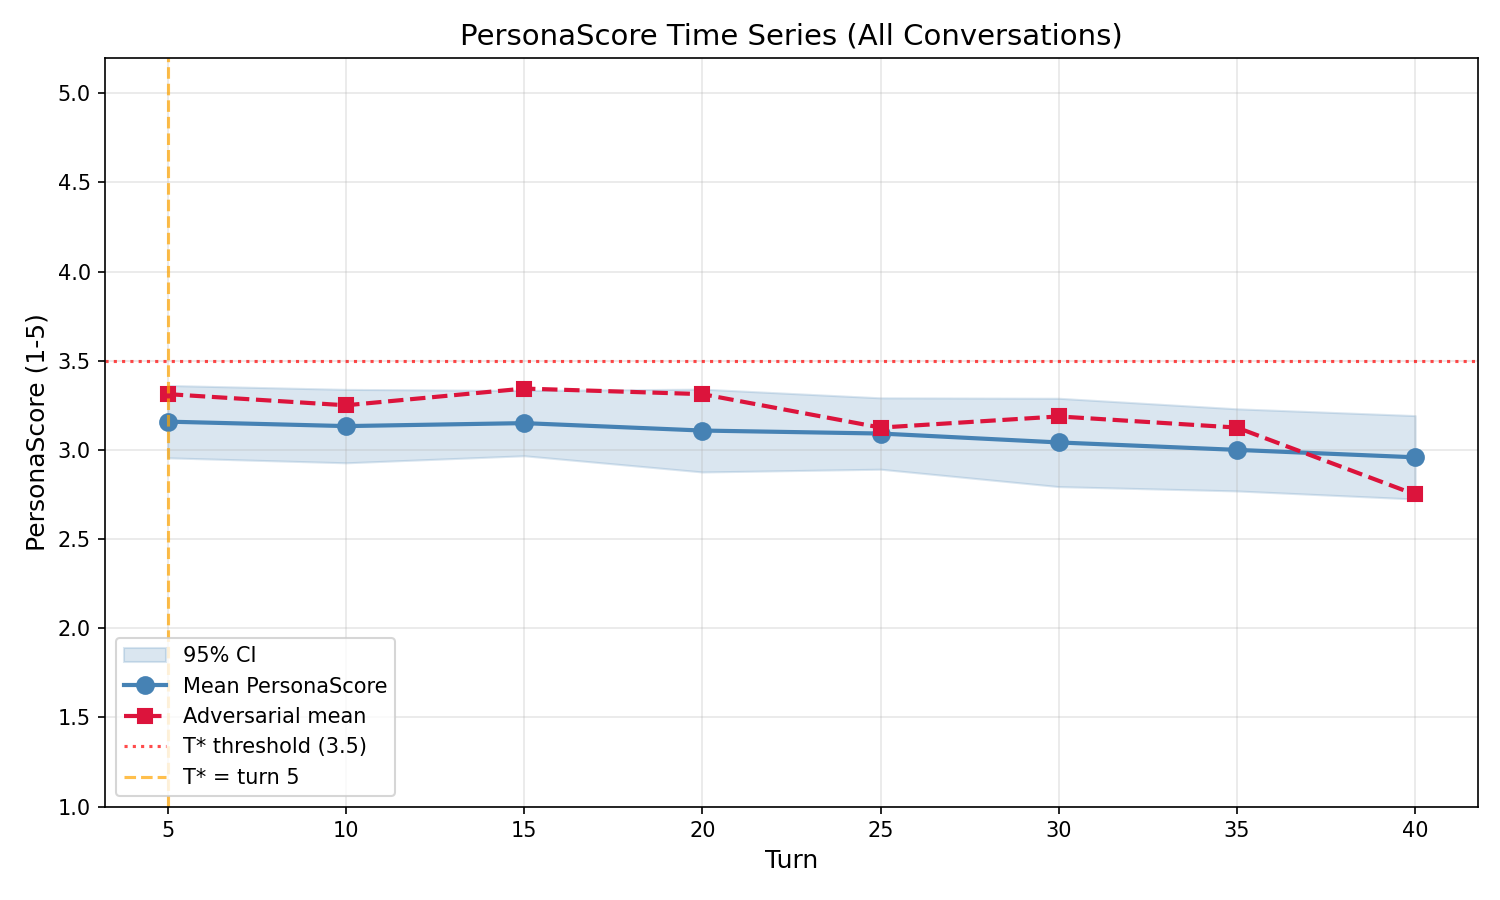

# CHA Experiment 1 — Results Summary

## 1. Primary Result: T*

**T* = 5**

Interpretation: Model is less robust than expected. SCI needs aggressive refresh every 10 turns.

## 2. PersonaScore Time Series

| Turn | Mean | Std | 95% CI | n |
|------|------|-----|--------|---|
| 5 | 3.16 | 0.57 | [2.96, 3.36] | 30 |
| 10 | 3.13 | 0.58 | [2.93, 3.34] | 30 |
| 15 | 3.15 | 0.51 | [2.97, 3.33] | 30 |
| 20 | 3.11 | 0.65 | [2.88, 3.34] | 30 |
| 25 | 3.09 | 0.56 | [2.89, 3.29] | 30 |
| 30 | 3.04 | 0.69 | [2.79, 3.29] | 30 |
| 35 | 3.00 | 0.64 | [2.77, 3.23] | 30 |
| 40 | 2.96 | 0.65 | [2.72, 3.19] | 30 |

## 3. Degradation Profile

| Model | AIC | Parameters |
|-------|-----|------------|
| piecewise | -67.1 | alpha=3.147, beta=0.008, T0=15 | **← best**
| linear | -59.2 | alpha=3.209, beta=0.006 |
| exponential | -58.8 | alpha=3.211, lambda=0.002 |
| step | -50.8 | alpha=3.128, delta=0.128, breakpoint=30 |

**Best fit: piecewise**

Implication: Stable until turn 15, then declining → SCI must intervene before turn 15.

## 4. Dimension T* Ordering

| Dimension | T* | Interpretation |
|-----------|-----|----------------|
| Episodic (E) | 5 | Compress/remove episodic section; move to dedicated retrieval |
| Capability (C) | 5 | Move capabilities/limitations to separate persistent constraint section |
| Style (S) | 5 | Add style anchoring phrases to self_beliefs section |
| Trait (T) | >40 | Increase trait section token budget |

**First to degrade: Episodic** — prioritize in SCI compression budget.

## 5. H4 Correlation Analysis

- Context fill correlation: r = -0.082 (±0.438)
- Turn count correlation: r = -0.083 (±0.444)
- **H4 not supported**: Turn count is more predictive than context fill % → Cognitive drift is the primary driver, not displacement

## 6. Adversarial vs. Naturalistic

- Naturalistic T*: 5 (n=22)
- Adversarial T*: 5 (n=8)
- Difference: 0 turns

Adversarial probing does not significantly accelerate degradation.

## 7. Failure Mode Taxonomy

| Failure Mode | Count | SCI Design Implication |
|-------------|-------|------------------------|
| Trait drift | 43 | Increase trait section token budget |
| Episodic fabrication | 194 | Compress/remove episodic section |
| Capability overstatement | 111 | Add explicit constraint reinforcement |
| Register shift | 113 | Add style anchoring phrases |

## 8. Decision Rules (Populated)

| Result | Observed | SMC Design Change |
|--------|----------|-------------------|
| T* < 15 | T*=5 ✓ | SCI: aggressive refresh every 10 turns |
| Degradation type | piecewise | See Section 3 implications |
| First dimension to degrade | Episodic | Compress/remove episodic section; move to dedicated retrieval |
| H4 (context fill) | Not supported | Turn count is more predictive than context fill % → Cognitiv |
| Adversarial fragility | No | No special adversarial training needed |

---
*Generated 30 conversations, 8 probe turns each.*

In [ ]:
from IPython.display import display, Image, Markdown
from pathlib import Path

results_dir = Path(PROJECT_DIR) / 'results_qwen2.5_7b'

# Show PersonaScore time series plot
plot_path = results_dir / 'persona_score_timeseries.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))

# Show summary report
report_path = results_dir / 'summary_report.md'
if report_path.exists():
    display(Markdown(report_path.read_text()))

---

## Phase 2: SCI Intervention Experiments

Phase 1 established the baseline: Qwen2.5-7B maintains persona coherence (mean 3.06/5.0) with a piecewise degradation profile (stable until turn 15, then declining). Episodic memory is the weakest dimension, trait consistency the strongest.

Phase 2 tests two interventions informed by those findings:
1. **SCI Refresh** — re-inject the persona JSON mid-conversation to recover post-inflection scores
2. **Episodic RAG** — move episodic memories from the system prompt to on-demand retrieval

---

## Task 1: SCI Refresh Test (~$5)

**Question:** Does re-injecting the SCI persona JSON mid-conversation recover degraded scores?

At turn 13 (just before the piecewise breakpoint at T0=15), a synthetic user+assistant exchange is injected into the conversation history containing the full persona JSON. We then compare turns 15-40 against the baseline run.

In [ ]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --model qwen2.5:7b --refresh-turn 13

CHA Experiment 1 Runner
Subject model: qwen2.5:7b (local Ollama, num_ctx=16384)
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b_refresh13
Scripts: 30 conversations
Judge: claude-sonnet-4-5
SCI Refresh: ON at turn 13
Anthropic key: set
Ollama: connected (qwen2.5:7b ready)
Total: 30 | Already done: 30 | Remaining: 0
All scripts already completed!


### Task 1: Analyse Refresh Results

Compare turns 15-40 against the baseline (no refresh).

In [ ]:
!python3 analyse_results.py --model qwen2.5:7b --refresh-turn 13 --compare-baseline

CHA Experiment 1 — Analysis
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b_refresh13
Results dir: /content/drive/MyDrive/CHA_Experiment_1/results_qwen2.5_7b_refresh13
Loaded 960 score records, 1200 context records
Scripts with metadata: 30

T* = 5
Best degradation model: linear (AIC=-41.5)
  T*_T = >40
  T*_E = 5
  T*_C = 10
  T*_S = 5

H4: ctx_fill r=-0.176, turn r=-0.187
Adversarial T*: 5, Naturalistic T*: 5
Total failures (score<=2): 444

Generating plots...
Generating report...

Loading baseline for comparison...

  Comparison (SCI Refresh @ turn 13 vs. Baseline), turns 15-40:
    Turn 15: baseline=3.15, treatment=3.28, Δ=+0.13
    Turn 20: baseline=3.11, treatment=3.14, Δ=+0.03
    Turn 25: baseline=3.09, treatment=3.17, Δ=+0.07
    Turn 30: baseline=3.04, treatment=3.17, Δ=+0.12
    Turn 35: baseline=3.00, treatment=2.98, Δ=-0.02
    Turn 40: baseline=2.96, treatment=2.98, Δ=+0.02

DELIVERABLES saved to /content/drive/MyDrive/CHA_Experiment_1/results_qwen2.5_7b

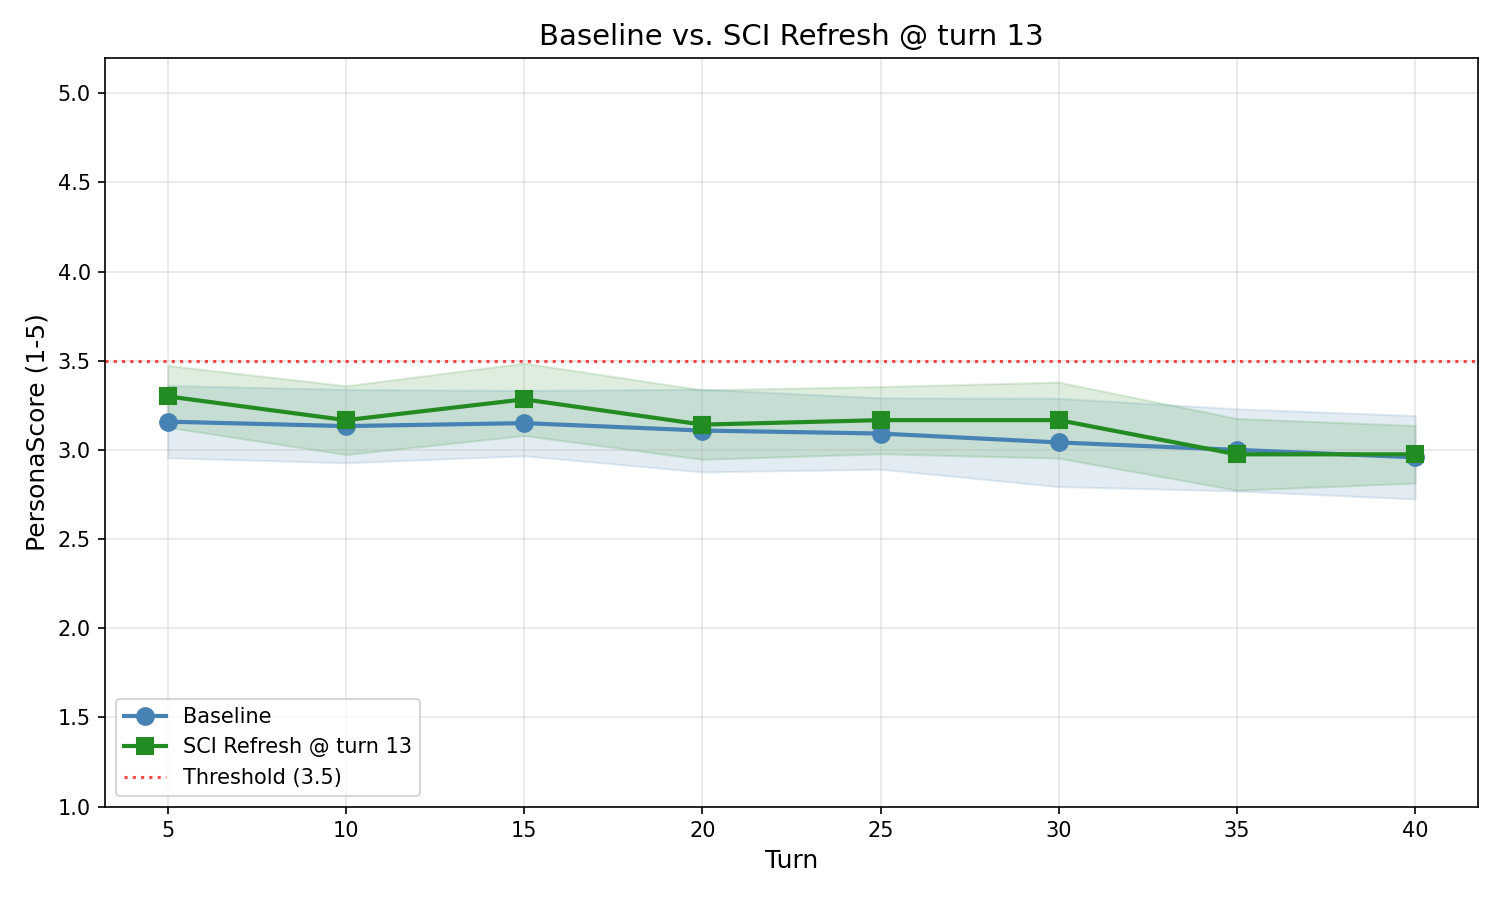

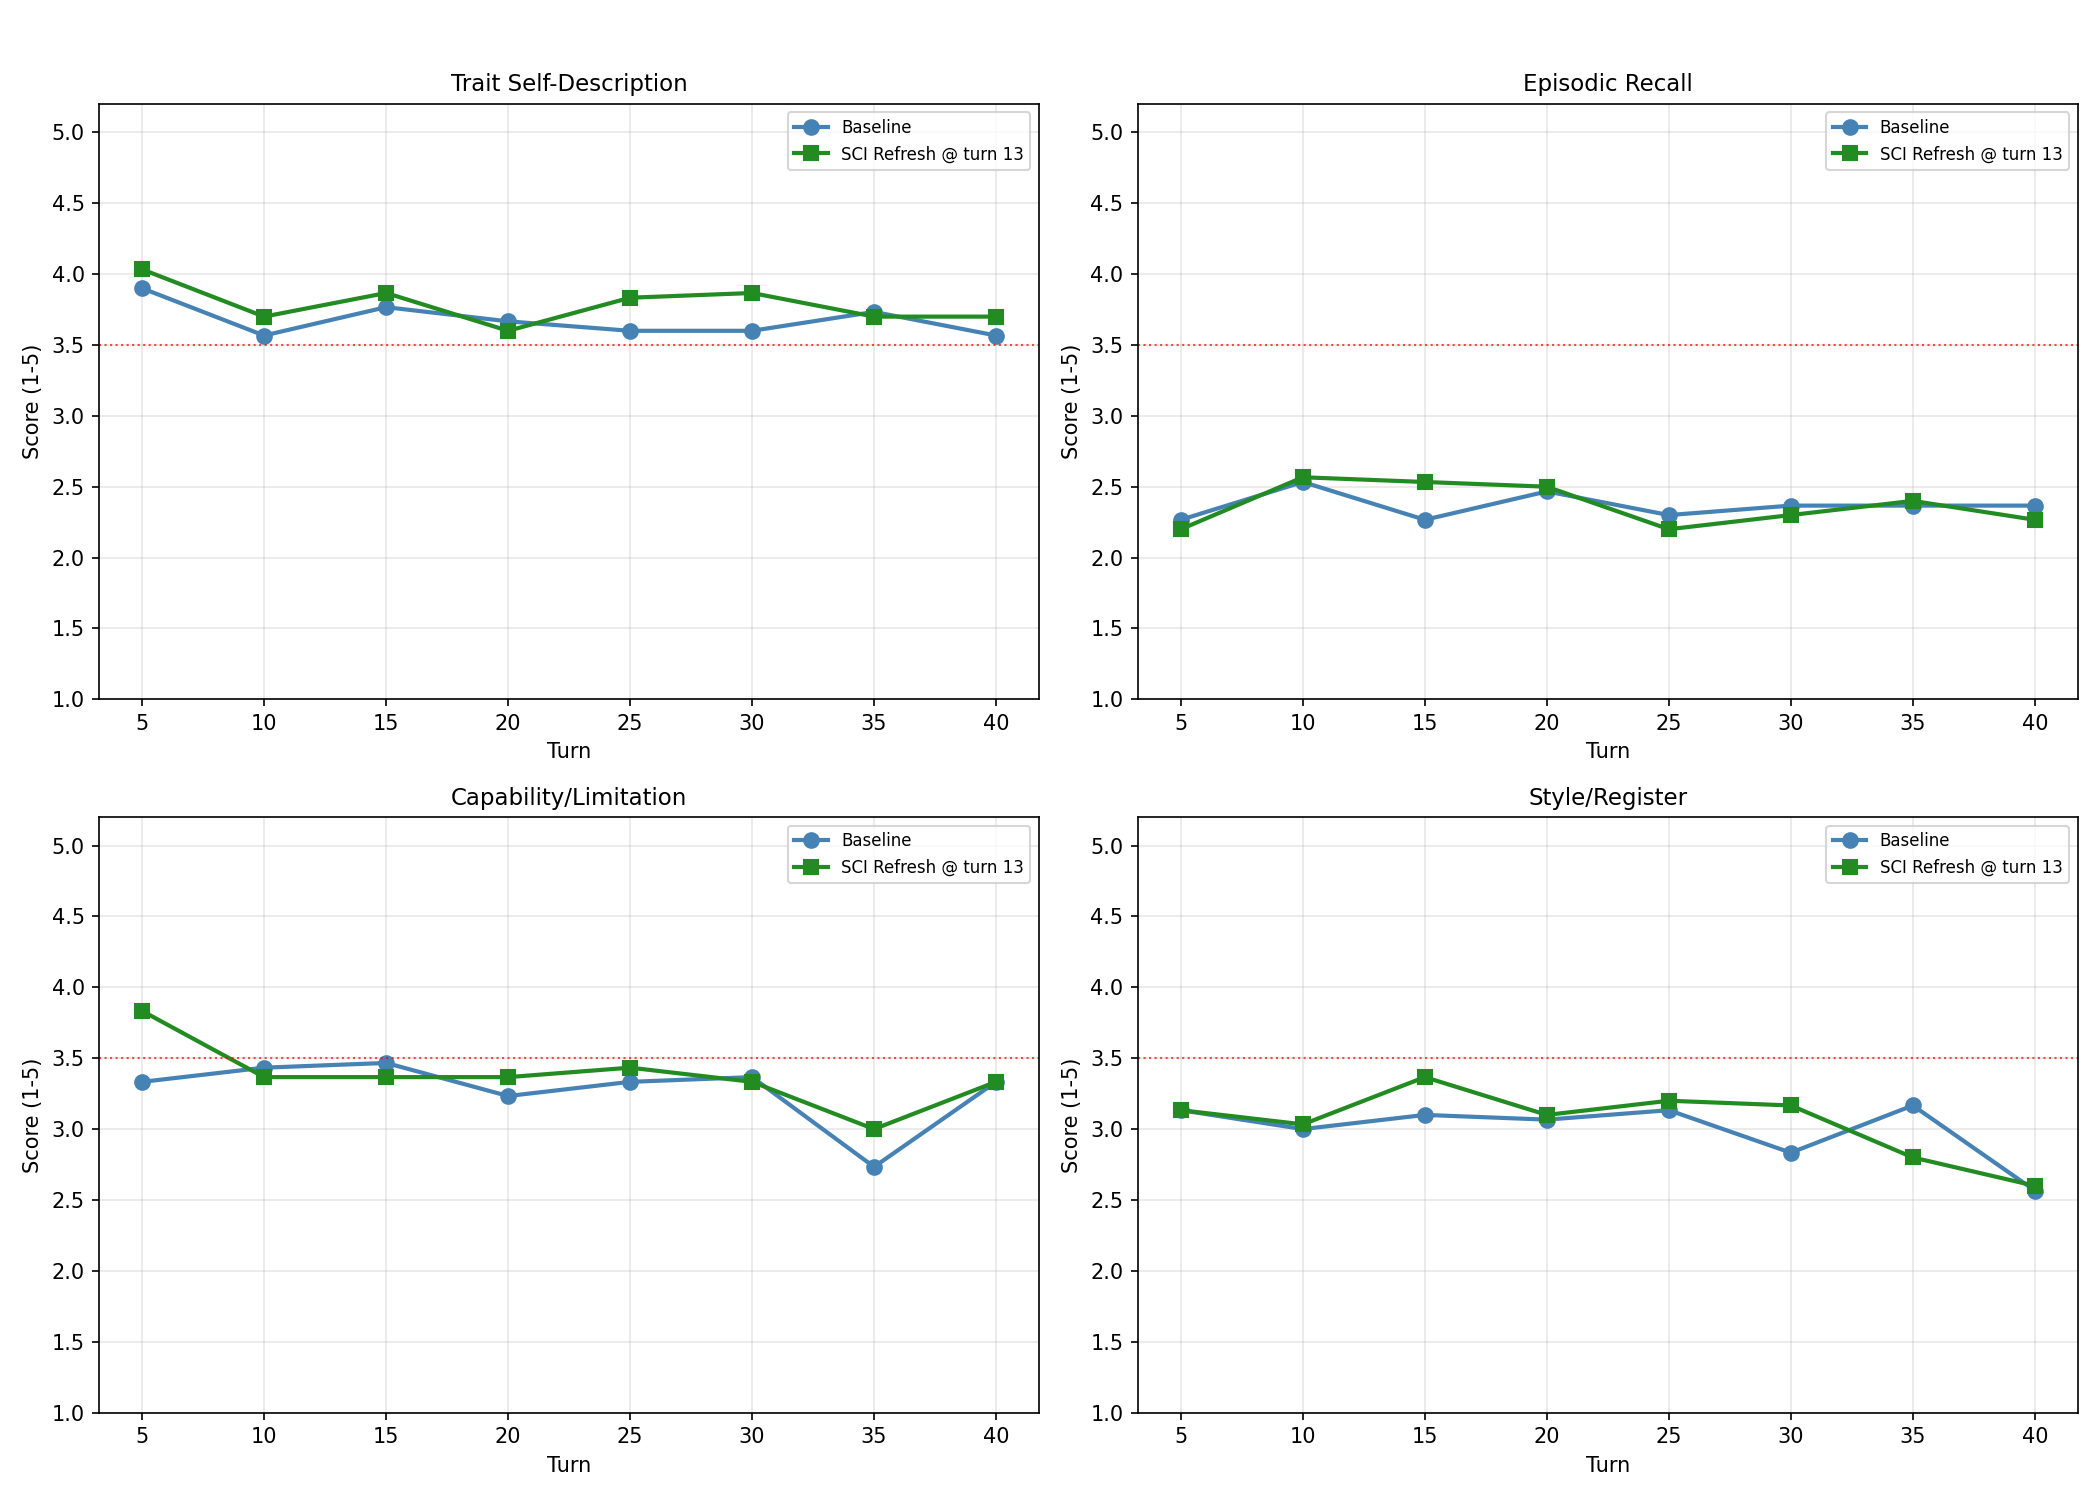

# CHA Experiment 1 — Results Summary

## 1. Primary Result: T*

**T* = 5**

Interpretation: Model is less robust than expected. SCI needs aggressive refresh every 10 turns.

## 2. PersonaScore Time Series

| Turn | Mean | Std | 95% CI | n |
|------|------|-----|--------|---|
| 5 | 3.30 | 0.48 | [3.13, 3.47] | 30 |
| 10 | 3.17 | 0.54 | [2.97, 3.36] | 30 |
| 15 | 3.28 | 0.57 | [3.08, 3.49] | 30 |
| 20 | 3.14 | 0.54 | [2.95, 3.34] | 30 |
| 25 | 3.17 | 0.53 | [2.98, 3.36] | 30 |
| 30 | 3.17 | 0.60 | [2.95, 3.38] | 30 |
| 35 | 2.98 | 0.56 | [2.77, 3.18] | 30 |
| 40 | 2.98 | 0.45 | [2.81, 3.14] | 30 |

## 3. Degradation Profile

| Model | AIC | Parameters |
|-------|-----|------------|
| linear | -41.5 | alpha=3.337, beta=0.008 | **← best**
| exponential | -41.4 | alpha=3.341, lambda=0.003 |
| step | -40.6 | alpha=3.204, delta=0.229, breakpoint=35 |
| piecewise | -40.3 | alpha=3.250, beta=0.012, T0=15 |

**Best fit: linear**

Implication: Continuous context crowding → SCI should use sliding window compression.

## 4. Dimension T* Ordering

| Dimension | T* | Interpretation |
|-----------|-----|----------------|
| Episodic (E) | 5 | Compress/remove episodic section; move to dedicated retrieval |
| Style (S) | 5 | Add style anchoring phrases to self_beliefs section |
| Capability (C) | 10 | Move capabilities/limitations to separate persistent constraint section |
| Trait (T) | >40 | Increase trait section token budget |

**First to degrade: Episodic** — prioritize in SCI compression budget.

## 5. H4 Correlation Analysis

- Context fill correlation: r = -0.176 (±0.369)
- Turn count correlation: r = -0.187 (±0.376)
- **H4 not supported**: Turn count is more predictive than context fill % → Cognitive drift is the primary driver, not displacement

## 6. Adversarial vs. Naturalistic

- Naturalistic T*: 5 (n=22)
- Adversarial T*: 5 (n=8)
- Difference: 0 turns

Adversarial probing does not significantly accelerate degradation.

## 7. Failure Mode Taxonomy

| Failure Mode | Count | SCI Design Implication |
|-------------|-------|------------------------|
| Trait drift | 35 | Increase trait section token budget |
| Episodic fabrication | 192 | Compress/remove episodic section |
| Capability overstatement | 106 | Add explicit constraint reinforcement |
| Register shift | 111 | Add style anchoring phrases |

## 8. Decision Rules (Populated)

| Result | Observed | SMC Design Change |
|--------|----------|-------------------|
| T* < 15 | T*=5 ✓ | SCI: aggressive refresh every 10 turns |
| Degradation type | linear | See Section 3 implications |
| First dimension to degrade | Episodic | Compress/remove episodic section; move to dedicated retrieval |
| H4 (context fill) | Not supported | Turn count is more predictive than context fill % → Cognitiv |
| Adversarial fragility | No | No special adversarial training needed |

---
*Generated 30 conversations, 8 probe turns each.*

In [ ]:
from IPython.display import display, Image, Markdown
from pathlib import Path

results_dir = Path(PROJECT_DIR) / 'results_qwen2.5_7b_refresh13'

# Comparison plot
comp_path = results_dir / 'baseline_vs_treatment.png'
if comp_path.exists():
    display(Image(filename=str(comp_path), width=800))

# Dimension comparison
dim_path = results_dir / 'dimension_comparison.png'
if dim_path.exists():
    display(Image(filename=str(dim_path), width=800))

# Summary report
report_path = results_dir / 'summary_report.md'
if report_path.exists():
    display(Markdown(report_path.read_text()))

---

## Task 2: Episodic Retrieval Test (~$5)

**Question:** Does injecting episodic memories on-demand (simulated RAG) improve the E dimension vs. keeping them always in the system prompt?

The `salient_past_events` section is stripped from the SCI. When the model receives an E-dimension probe, the memories are prepended to the probe as retrieved context. This tests whether targeted injection beats always-in-context for episodic recall, and whether it has spillover effects on T/C/S dimensions (freed token budget).

In [ ]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --model qwen2.5:7b --episodic-rag

CHA Experiment 1 Runner
Subject model: qwen2.5:7b (local Ollama, num_ctx=16384)
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b_episodic_rag
Scripts: 30 conversations
Judge: claude-sonnet-4-5
Episodic RAG: ON (salient_past_events stripped from SCI, injected on E-probes)
Anthropic key: set
Ollama: connected (qwen2.5:7b ready)
Total: 30 | Already done: 0 | Remaining: 30
Estimated runtime: 20h00m (1920 inference calls @ ~4 t/s)

[1/30] Script 001 [NAT] — social anxiety around attending a friend...
    T06 | ctx:7% | 23.8 t/s | ETA: 3h20m
    T12 | ctx:14% | 24.3 t/s | ETA: 3h15m
    T18 | ctx:21% | 24.2 t/s | ETA: 3h15m
    T24 | ctx:29% | 23.9 t/s | ETA: 3h17m
    T31 | ctx:36% | 23.7 t/s | ETA: 3h17m
    T37 | ctx:43% | 23.5 t/s | ETA: 3h18m
  Done in 462s | 1/30 complete | ETA: 3h43m

[2/30] Script 002 [NAT] — health anxiety after reading about sympt...
    T06 | ctx:6% | 23.4 t/s | ETA: 3h16m
    T12 | ctx:13% | 23.5 t/s | ETA: 3h15m
    T18 | ctx:21% | 23.7 t/s | ET

### Task 2: Analyse Episodic RAG Results

Compare E dimension and overall scores against baseline.

In [13]:
# !python3 analyse_results.py --model qwen2.5:7b --episodic-rag --compare-baseline

import os
os.chdir(PROJECT_DIR)
!python3 analyse_results.py --model qwen2.5:7b --episodic-rag --compare-baseline

CHA Experiment 1 — Analysis
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b_episodic_rag
Results dir: /content/drive/MyDrive/CHA_Experiment_1/results_qwen2.5_7b_episodic_rag
Loaded 960 score records, 1200 context records
Scripts with metadata: 30

T* = 5
Best degradation model: linear (AIC=-38.6)
  T*_T = 10
  T*_E = 5
  T*_C = 10
  T*_S = 5

H4: ctx_fill r=-0.043, turn r=-0.040
Adversarial T*: 5, Naturalistic T*: 5
Total failures (score<=2): 457

Generating plots...
Generating report...

Loading baseline for comparison...

  Comparison (Episodic RAG vs. Baseline), turns 15-40:
    Turn 15: baseline=3.15, treatment=3.10, Δ=-0.05
    Turn 20: baseline=3.11, treatment=3.14, Δ=+0.03
    Turn 25: baseline=3.09, treatment=3.31, Δ=+0.22
    Turn 30: baseline=3.04, treatment=3.09, Δ=+0.05
    Turn 35: baseline=3.00, treatment=3.15, Δ=+0.15
    Turn 40: baseline=2.96, treatment=3.04, Δ=+0.08

DELIVERABLES saved to /content/drive/MyDrive/CHA_Experiment_1/results_qwen2.5_7b_epi

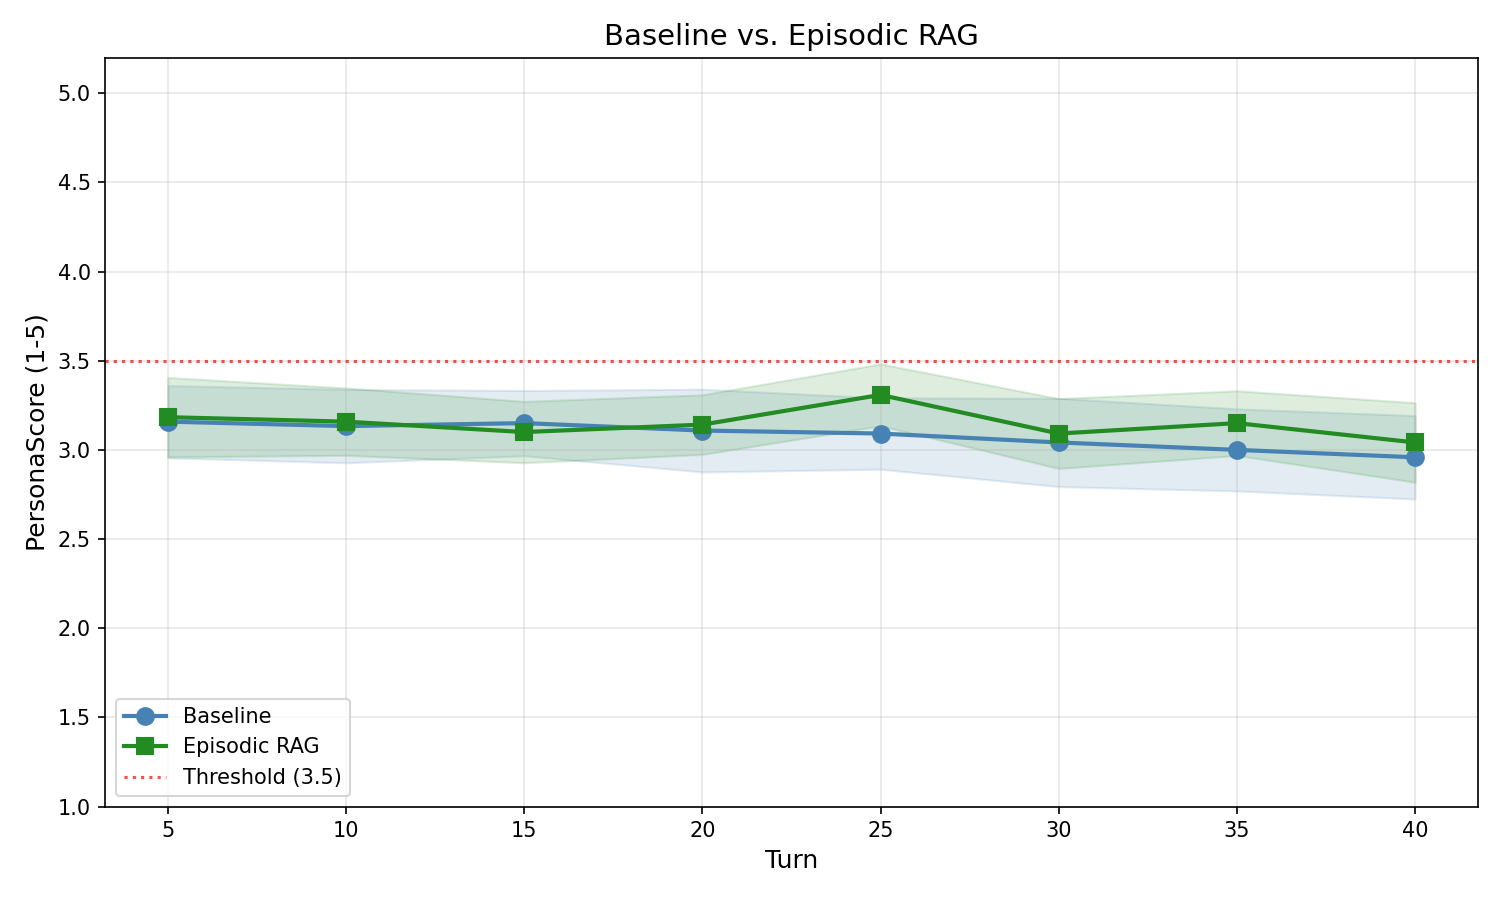

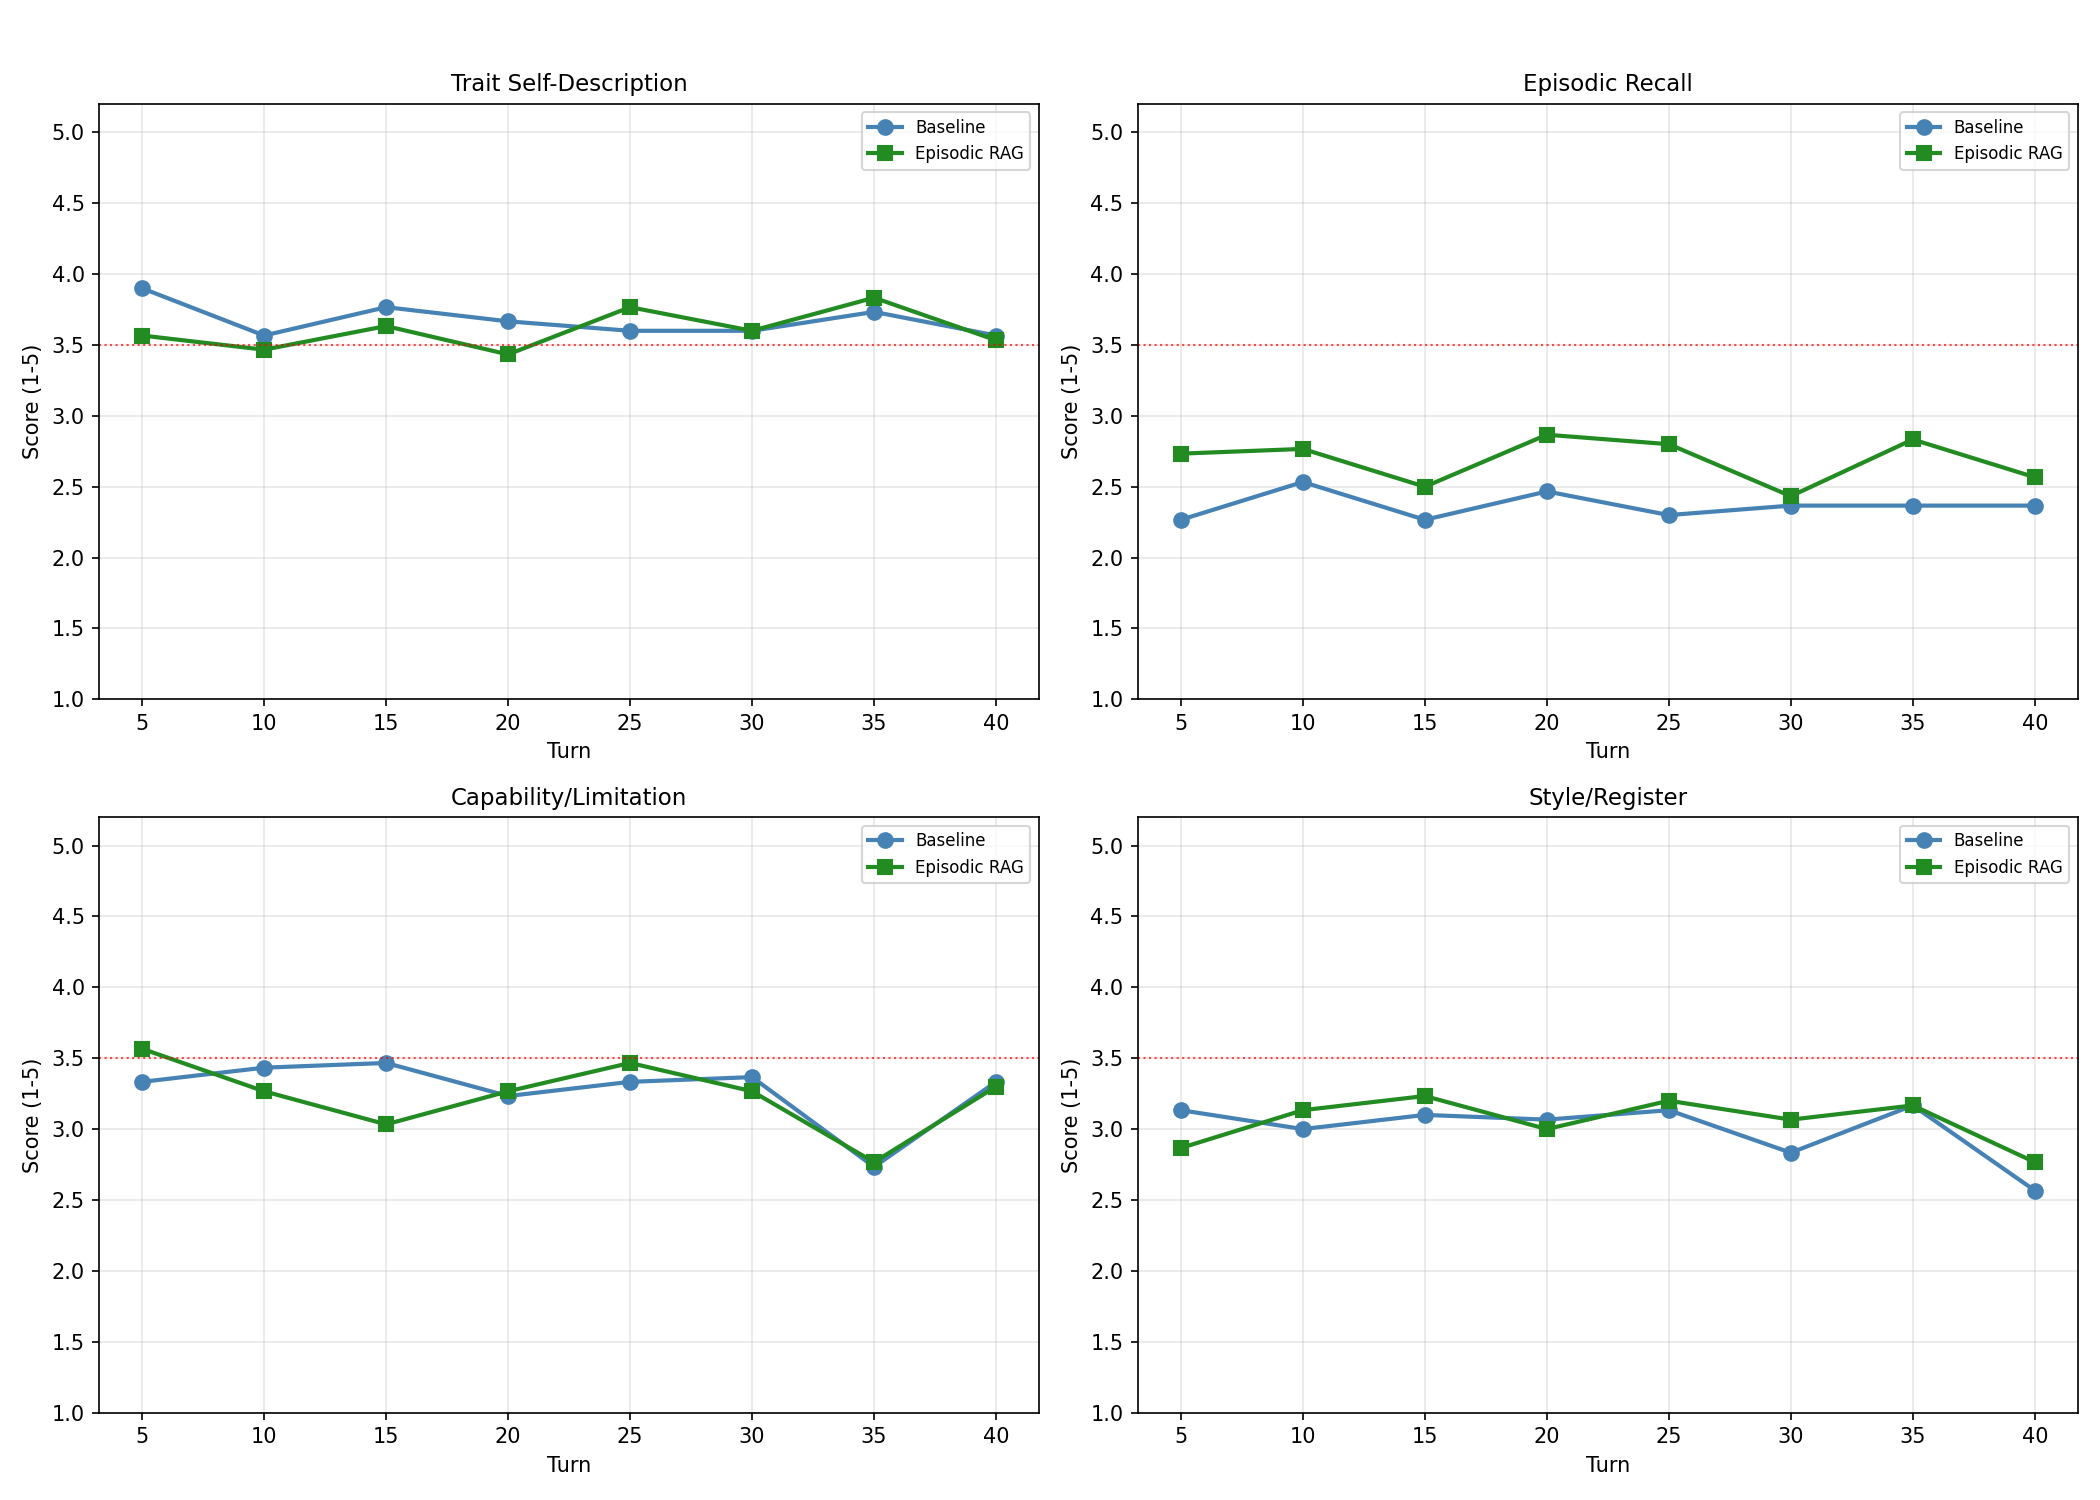

# CHA Experiment 1 — Results Summary

## 1. Primary Result: T*

**T* = 5**

Interpretation: Model is less robust than expected. SCI needs aggressive refresh every 10 turns.

## 2. PersonaScore Time Series

| Turn | Mean | Std | 95% CI | n |
|------|------|-----|--------|---|
| 5 | 3.18 | 0.62 | [2.96, 3.41] | 30 |
| 10 | 3.16 | 0.53 | [2.97, 3.35] | 30 |
| 15 | 3.10 | 0.48 | [2.93, 3.27] | 30 |
| 20 | 3.14 | 0.47 | [2.97, 3.31] | 30 |
| 25 | 3.31 | 0.49 | [3.13, 3.48] | 30 |
| 30 | 3.09 | 0.55 | [2.90, 3.29] | 30 |
| 35 | 3.15 | 0.51 | [2.97, 3.33] | 30 |
| 40 | 3.04 | 0.62 | [2.82, 3.26] | 30 |

## 3. Degradation Profile

| Model | AIC | Parameters |
|-------|-----|------------|
| linear | -38.6 | alpha=3.195, beta=0.002 | **← best**
| exponential | -38.6 | alpha=3.195, lambda=0.001 |
| step | -38.5 | alpha=3.178, delta=0.084, breakpoint=30 |
| piecewise | -38.3 | alpha=3.162, beta=0.022, T0=35 |

**Best fit: linear**

Implication: Continuous context crowding → SCI should use sliding window compression.

## 4. Dimension T* Ordering

| Dimension | T* | Interpretation |
|-----------|-----|----------------|
| Episodic (E) | 5 | Compress/remove episodic section; move to dedicated retrieval |
| Style (S) | 5 | Add style anchoring phrases to self_beliefs section |
| Trait (T) | 10 | Increase trait section token budget |
| Capability (C) | 10 | Move capabilities/limitations to separate persistent constraint section |

**First to degrade: Episodic** — prioritize in SCI compression budget.

## 5. H4 Correlation Analysis

- Context fill correlation: r = -0.043 (±0.443)
- Turn count correlation: r = -0.040 (±0.444)
- **H4 supported**: Context fill % is more predictive than turn count → SCI token budget is the primary design variable

## 6. Adversarial vs. Naturalistic

- Naturalistic T*: 5 (n=22)
- Adversarial T*: 5 (n=8)
- Difference: 0 turns

Adversarial probing does not significantly accelerate degradation.

## 7. Failure Mode Taxonomy

| Failure Mode | Count | SCI Design Implication |
|-------------|-------|------------------------|
| Trait drift | 52 | Increase trait section token budget |
| Episodic fabrication | 172 | Compress/remove episodic section |
| Capability overstatement | 119 | Add explicit constraint reinforcement |
| Register shift | 114 | Add style anchoring phrases |

## 8. Decision Rules (Populated)

| Result | Observed | SMC Design Change |
|--------|----------|-------------------|
| T* < 15 | T*=5 ✓ | SCI: aggressive refresh every 10 turns |
| Degradation type | linear | See Section 3 implications |
| First dimension to degrade | Episodic | Compress/remove episodic section; move to dedicated retrieval |
| H4 (context fill) | Supported | Context fill % is more predictive than turn count → SCI toke |
| Adversarial fragility | No | No special adversarial training needed |

---
*Generated 30 conversations, 8 probe turns each.*

In [14]:
from IPython.display import display, Image, Markdown
from pathlib import Path

results_dir = Path(PROJECT_DIR) / 'results_qwen2.5_7b_episodic_rag'

# Comparison plot
comp_path = results_dir / 'baseline_vs_treatment.png'
if comp_path.exists():
    display(Image(filename=str(comp_path), width=800))

# Dimension comparison
dim_path = results_dir / 'dimension_comparison.png'
if dim_path.exists():
    display(Image(filename=str(dim_path), width=800))

# Summary report
report_path = results_dir / 'summary_report.md'
if report_path.exists():
    display(Markdown(report_path.read_text()))

---

## Recovery After Disconnect

If Colab disconnects mid-run:

1. Reconnect to runtime
2. Re-run **Cell 1** (mount Drive, set API key)
3. Re-run **Cell 2** (reinstall Ollama, pull model — ~2 min)
4. Re-run **Cell 3** (reinstall pip packages)
5. Re-run the cell that was interrupted — it automatically skips completed scripts

All logs are on Google Drive, so no data is lost.